# Behaviour Cloning Evaluation

In [1]:
import sys
import os
import torch
import pandas as pd

if 'google.colab' in sys.modules:
  from google.colab import drive
  drive.mount( "/content/drive")
  if os.path.isdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks'):
    os.chdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks')


project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

torch_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Test Evaluation

In [2]:
from src.utils.evaluation import print_model_eval_results, evaluate_model_test_dataset
from src.utils.plotting import plot_confusion_matrix_heatmap

C:\Users\Miro\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Replay Buffer

Model Evaluation results of BC Replay Buffer
accuracy: 0.9217844784488252
balanced_accuracy: 0.9474108151511765
precision_macro: 0.854735223874944
recall_macro: 0.9474108151511765
f1_macro: 0.8921902450164645
precision_weighted: 0.9373440046331215
recall_weighted: 0.9217844784488252
f1_weighted: 0.924648074702942
precision_per_class: [0.9623135  0.72939184 0.9939723  0.73326326]
recall_per_class: [0.98262113 0.96654553 0.87926834 0.96120827]
f1_per_class: [0.97236129 0.83138733 0.93310849 0.83190387]
confusion_matrix: [[26122   199    85   178]
 [  100  9043   102   111]
 [  796  3032 49800  3010]
 [  127   124   115  9069]]
classification_report:
  0: {'precision': 0.9623135015656659, 'recall': 0.9826211254890159, 'f1-score': 0.9723612946453498, 'support': 26584.0}
  1: {'precision': 0.729391837393128, 'recall': 0.9665455322787516, 'f1-score': 0.8313873310655512, 'support': 9356.0}
  2: {'precision': 0.9939722965151092, 'recall': 0.8792683357463187, 'f1-score': 0.9331084879145587, 'su

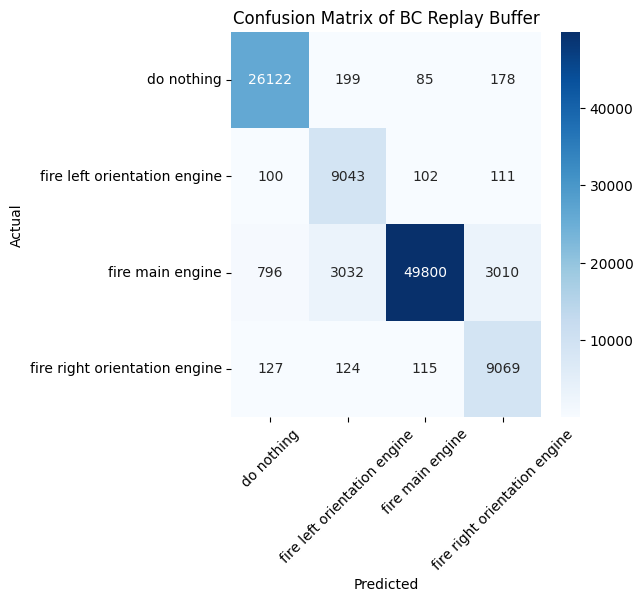

In [3]:
rb_norm_name = 'standard'

rb_test_df = pd.read_parquet('../../data/replay_buffer_episodes/rb_test.parquet').drop(columns=['done', 'episode'])
rb_normalization_technique = torch.jit.load(f'../../models/BC/replay_buffer/normalization/{rb_norm_name}_normalization.pt')
rb_model = torch.jit.load(f'../../models/BC/replay_buffer/BC_{rb_norm_name}.pt')

rb_classificiation_repport_dict, rb_confusion_matrix = evaluate_model_test_dataset(model=rb_model,
                            device=torch_device,
                            test_df=rb_test_df,
                            norm_technique_script=rb_normalization_technique,
                            selected_features=['X', 'Y', 'lv_X', 'lv_Y', 'reward', 'angle', 'angular_velocity', 'leg_1', 'leg_2'])

rb_confusion_matrix_fig = plot_confusion_matrix_heatmap(confusion_matrix=rb_confusion_matrix,
                                                        model_name='BC Replay Buffer',
                                                        f_size=(5,5))

print_model_eval_results(rb_classificiation_repport_dict,
                         model_name='BC Replay Buffer')

### Final Policy

Model Evaluation results of BC Final Policy
accuracy: 0.992147363108756
balanced_accuracy: 0.9952380643101022
precision_macro: 0.9785180293670996
recall_macro: 0.9952380643101022
f1_macro: 0.98669767385174
precision_weighted: 0.9923244995006076
recall_weighted: 0.992147363108756
f1_weighted: 0.9921797989380076
precision_per_class: [0.99082326 0.95804549 0.99957006 0.9656333 ]
recall_per_class: [0.99524344 0.99806916 0.98892218 0.99871748]
f1_per_class: [0.99302843 0.97764787 0.99421761 0.98189678]
confusion_matrix: [[33687    85    20    56]
 [    8  5686     2     1]
 [  299   163 53473   137]
 [    5     1     1  5451]]
classification_report:
  0: {'precision': 0.9908232595076326, 'recall': 0.99524344126684, 'f1-score': 0.9930284316181998, 'support': 33848.0}
  1: {'precision': 0.9580454928390901, 'recall': 0.9980691592066, 'f1-score': 0.9776478679504814, 'support': 5697.0}
  2: {'precision': 0.9995700613129954, 'recall': 0.9889221778369581, 'f1-score': 0.9942176111854827, 'support':

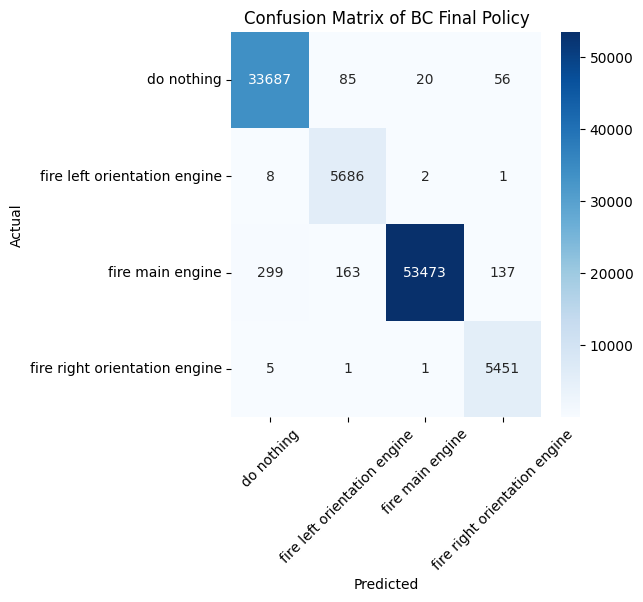

In [4]:
fp_norm_name = 'standard'

fp_test_df = pd.read_parquet('../../data/final_policy_episodes/fp_test.parquet').drop(columns=['done', 'episode'])
fp_normalization_technique = torch.jit.load(f'../../models/BC/final_policy/normalization/{fp_norm_name}_normalization.pt')
fp_model = torch.jit.load(f'../../models/BC/final_policy/BC_{fp_norm_name}.pt')


fp_classificiation_repport_dict, fp_confusion_matrix = evaluate_model_test_dataset(model=fp_model,
                            device=torch_device,
                            test_df=fp_test_df,
                            norm_technique_script=fp_normalization_technique,
                            selected_features=['X', 'Y', 'lv_X', 'lv_Y', 'reward', 'angle', 'angular_velocity', 'leg_1', 'leg_2'])

fp_confusion_matrix_fig = plot_confusion_matrix_heatmap(confusion_matrix=fp_confusion_matrix,
                                                        model_name='BC Final Policy',
                                                        f_size=(5,5))

print_model_eval_results(fp_classificiation_repport_dict,
                         model_name='BC Final Policy')

## Evaluation in the Live Environment for 1000 episodes

In [5]:
import yaml
import warnings

from src.utils.live_env_testing import BC_evaluate_model_in_live_env

warnings.filterwarnings("ignore")
with open('../../config/bc_live_env_elavuation_config.yaml', 'r') as f:
    bc_live_env_config_config = yaml.safe_load(f)

### Replay Buffer

In [6]:
rb_rewards = BC_evaluate_model_in_live_env(
    env_test_params=bc_live_env_config_config,
    model_name='replay_buffer',
    norm_technique=rb_normalization_technique,
    model = rb_model
)

100%|██████████| 1000/1000 [00:52<00:00, 19.16it/s]


### Final Policy

In [7]:
fp_rewards = BC_evaluate_model_in_live_env(
    env_test_params=bc_live_env_config_config,
    norm_technique=fp_normalization_technique,
    model_name='final_policy',
    model = fp_model
)

100%|██████████| 1000/1000 [11:07<00:00,  1.50it/s]


### Accumulated rewards distribution comparison

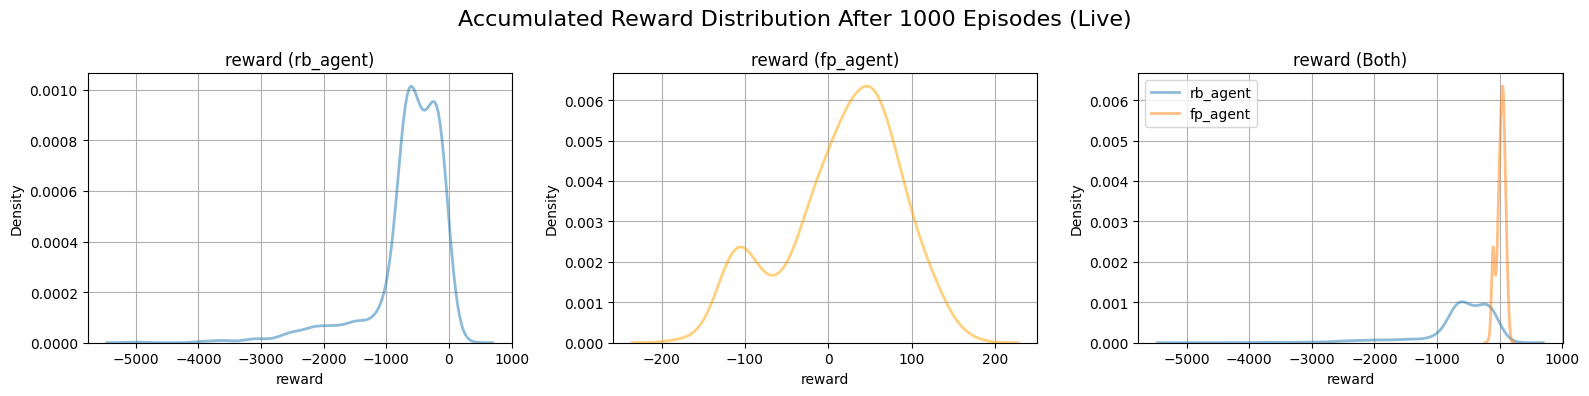

In [8]:
from src.utils.plotting import plot_univariate_analysis


rb_rewards_df = pd.DataFrame(rb_rewards, columns=['reward'])
fp_rewards_df = pd.DataFrame(fp_rewards, columns=['reward'])

rb_fp_combined_fig = plot_univariate_analysis(
        df1_name = 'rb_agent',
        df2_name = 'fp_agent',
        df1=rb_rewards_df,
        df2=fp_rewards_df,
        num_columns=3,
        custom_title='Accumulated Reward Distribution After 1000 Episodes (Live)',
        kde_kwargs={'linewidth': 2, 'alpha': 0.5},
        f_size=(16,4))
rb_fp_combined_fig.savefig('../../plots/liven_env_1000_ep_eval_rb_fp.jpg')